In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# 2. Import Library
# ==========================================================
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# ==========================================================
# 3. Membaca Dataset
# ==========================================================
folder_path = "/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Tiktok"

embedding_df = pd.read_csv(os.path.join(folder_path, "tt_embed_lightgbm.csv"))
label_df = pd.read_csv(os.path.join(folder_path, "tt_pseudo.csv"))

print("Embedding :", embedding_df.shape)
print("Pseudo    :", label_df.shape)

Embedding : (16035, 769)
Pseudo    : (16035, 3)


In [4]:
# ==========================================================
# 4. Merge Dataset
# ==========================================================
df = pd.merge(
    embedding_df,
    label_df[["tt_clean", "label_sentimen", "confidence_score"]],
    on="tt_clean",
    how="inner"
)

print(df.head())
print(df.shape)

                                        tt_clean     emb_0     emb_1  \
0              woilah temen gw berenang disitu😹😹  0.210349 -0.099673   
1                                uya kuya kapan🗿  0.253793 -1.116056   
2                         "woy ini mahal anj" 😭😭  0.328317 -0.458590   
3  jangan lupa eko patrio, uya kuya, nafa ubach,  0.289145 -0.280991   
4    reaksi syahroni pulang kaget jadi gelandang -0.340336 -0.180791   

      emb_2     emb_3     emb_4     emb_5     emb_6     emb_7     emb_8  ...  \
0 -0.429247 -0.751538 -0.607294 -0.726231  0.270705  0.483862 -0.115469  ...   
1 -0.498299  0.366308  0.078964 -1.011265  0.783763  0.410047  0.242735  ...   
2 -0.514302  0.307351 -0.471466 -0.630849 -0.180228 -0.056246  0.138870  ...   
3 -0.623420  0.761281 -0.307501 -0.385936  1.022714  0.453613  0.338677  ...   
4 -0.684845 -0.147271 -0.306911 -0.819866  0.654910  0.559863 -0.109508  ...   

    emb_760   emb_761   emb_762   emb_763   emb_764   emb_765   emb_766  \
0  1.153662

In [5]:
# ==========================================================
# 5. Filter Confidence Score
# ==========================================================
# Gunakan jika ingin hanya memakai pseudo label yang yakin

df = df[df["confidence_score"] >= 0.80].reset_index(drop=True)

print("Jumlah data setelah filter :", len(df))

Jumlah data setelah filter : 12879


In [6]:
# ==========================================================
# 6. Menentukan Feature dan Label
# ==========================================================
embedding_cols = [col for col in df.columns if col.startswith("emb_")]

X = df[embedding_cols].values

y = df["label_sentimen"]

print("Jumlah fitur :", len(embedding_cols))
print("Shape X :", X.shape)

Jumlah fitur : 768
Shape X : (12879, 768)


In [7]:
# ==========================================================
# 7. Label Encoding
# ==========================================================
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Label kelas :", encoder.classes_)

Label kelas : ['negative' 'neutral' 'positive']


In [8]:
# ==========================================================
# 8. Train Test Split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (10303, 768)
Test  : (2576, 768)


In [9]:
# ==========================================================
# 9. Training LightGBM
# ==========================================================
model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    learning_rate=0.05,
    n_estimators=300,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.253626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 10303, number of used features: 768
[LightGBM] [Info] Start training from score -0.502257
[LightGBM] [Info] Start training from score -1.634798
[LightGBM] [Info] Start training from score -1.610215


LGBMClassifier(learning_rate=0.05, n_estimators=300, num_class=3,
               objective='multiclass', random_state=42)

In [10]:
# ==========================================================
# 10. Prediksi
# ==========================================================
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
# ==========================================================
# 11. Evaluasi Model
# ==========================================================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*50)
print("HASIL EVALUASI LIGHTGBM")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

HASIL EVALUASI LIGHTGBM
Accuracy  : 0.8952
Precision : 0.8960
Recall    : 0.8952
F1 Score  : 0.8928


In [12]:
# ==========================================================
# 12. Classification Report
# ==========================================================
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

    negative       0.89      0.97      0.93      1559
     neutral       0.88      0.80      0.84       502
    positive       0.92      0.77      0.84       515

    accuracy                           0.90      2576
   macro avg       0.90      0.84      0.87      2576
weighted avg       0.90      0.90      0.89      2576



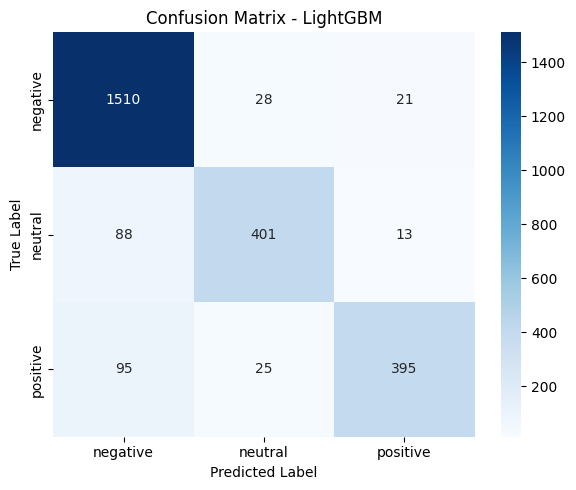

In [13]:
# ==========================================================
# 13. Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [14]:
# ==========================================================
# Prediksi Seluruh Dataset
# ==========================================================
df["prediksi"] = model.predict(X)

# Mengembalikan label angka menjadi label asli
df["prediksi"] = encoder.inverse_transform(df["prediksi"])

df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,tt_clean,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,label_sentimen,confidence_score,prediksi
0,uya kuya kapan🗿,0.253793,-1.116056,-0.498299,0.366308,0.078964,-1.011265,0.783763,0.410047,0.242735,...,-0.566681,-0.536137,0.064852,-0.474909,-0.249761,0.303375,0.692585,neutral,0.910259,neutral
1,"""woy ini mahal anj"" 😭😭",0.328317,-0.458590,-0.514302,0.307351,-0.471466,-0.630849,-0.180228,-0.056246,0.138870,...,-0.670980,-0.983200,-0.149698,0.835711,-0.068866,0.177685,0.268910,negative,0.993690,negative
2,"jangan lupa eko patrio, uya kuya, nafa ubach,",0.289145,-0.280991,-0.623420,0.761281,-0.307501,-0.385936,1.022714,0.453613,0.338677,...,-0.389492,0.249197,-0.741517,-0.883760,-0.434740,0.053079,0.409794,neutral,0.993353,neutral
3,reaksi syahroni pulang kaget jadi gelandang,-0.340336,-0.180791,-0.684845,-0.147271,-0.306911,-0.819866,0.654910,0.559863,-0.109508,...,0.343889,-0.382264,0.155154,-0.516776,-0.629965,-0.649632,0.181944,neutral,0.991177,neutral
4,yg ambil ironman keren anjir itu mahal banget,1.034936,-0.101655,-0.108467,-0.394614,-0.022183,-0.680481,-0.374482,0.846906,-0.550158,...,-0.359241,-0.838393,-0.278288,0.525935,-0.882676,-0.938960,0.401736,positive,0.870074,positive


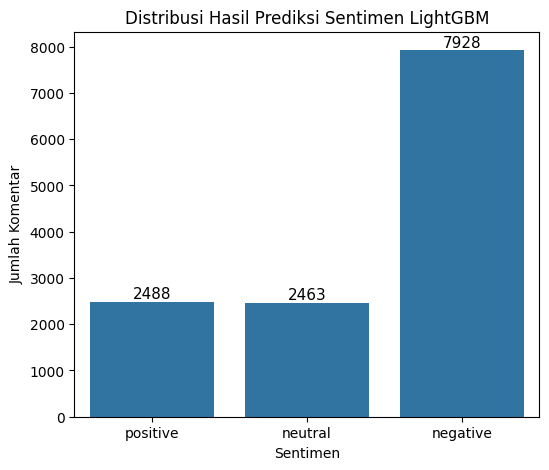

In [15]:
# ==========================================================
# Bar Chart + Jumlah
# ==========================================================
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="prediksi",
    order=["positive","neutral","negative"]
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribusi Hasil Prediksi Sentimen LightGBM")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")

plt.show()

In [16]:
df = df[df["confidence_score"] > 0.8].reset_index(drop=True)

print(f"Jumlah data setelah filter: {len(df):,}")
print(df["label_sentimen"].value_counts())

Jumlah data setelah filter: 12,879
label_sentimen
negative    7794
positive    2574
neutral     2511
Name: count, dtype: int64
